# First Break Picking — Prediction Demo (adapted from hardpicks)

Adapted from `hardpicks/examples/local/fbp_predict_with_api.ipynb` for this repo.

- Reloads a pretrained **FBPUNet** checkpoint (default: `output/train_<site>/best*.ckpt` from the training notebook)
- Runs inference on **NPZ** or live **HDF5** with the **same preprocessing** as training (no augs, no time crop)
- Scores HitRate / MAE / MBE when ground-truth picks are present, then overlays predicted picks on gathers
- Optional **test-time flip ensemble** at the end

This notebook does **not** retrain. If the site is far from the training distribution, picks can be useless.

**Requirements:** `hardpicks` + `torch` + `pytorch-lightning`. A GPU is strongly recommended.
Run `fbp_train_with_api.ipynb` first (or set `FBP_CKPT_PATH` to an existing `.ckpt`).


In [1]:
from __future__ import annotations

import functools
import logging
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torch.utils.data
import tqdm

REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import hardpicks
from seismic_utils.hardpicks_pl_compat import ensure_hardpicks_lightning_compat

print("PL compat:", ensure_hardpicks_lightning_compat())

import hardpicks.data.fbp.data_module as fbp_data_module
import hardpicks.data.fbp.gather_transforms as fbp_data_transforms
import hardpicks.metrics.fbp.utils as metrics_utils
import hardpicks.models.fbp.unet as fbp_unet
import hardpicks.models.fbp.utils as model_utils
from seismic_utils.dataset import DEFAULT_DATA_DIR, ShotGather
from seismic_utils.hardpicks_bridge import hardpicks_available, resolve_hardpicks_site_info
from seismic_utils.npz_parser import create_npz_parser
from seismic_utils.plotting import plot_shot_gather

assert hardpicks_available(), "hardpicks (+ torch) required — run setup_lightning.sh / install requirements"
print("torch", torch.__version__, "| cuda", torch.cuda.is_available(), "| pl", pl.__version__)
print("hardpicks", hardpicks.__file__)
print("DATA_DIR", DEFAULT_DATA_DIR)

/home/mika/anaconda3/envs/seismic_activity/lib/python3.11/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/mika/anaconda3/envs/seismic_activity/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PL compat: pl-2.4.0-patched-v2
torch 2.4.1+cu121 | cuda True | pl 2.4.0
hardpicks /home/mika/dev/seismic_activity/src/hardpicks/hardpicks/__init__.py
DATA_DIR /home/mika/data/seismic_activity


In [ ]:
# ---------------- user knobs ----------------
SITE_NAME = "Halfmile"  # Brunswick | Halfmile | Lalor | Sudbury
# "npz" = fast per-gather files under NPZ_ROOT (recommended after export)
# "hdf5" = live hardpicks HDF5 parser (slower I/O)
DATA_BACKEND = os.environ.get("FBP_DATA_BACKEND", "hdf5")  # npz | hdf5
DATA_DIR = Path(os.environ.get("SEISMIC_DATA_DIR", DEFAULT_DATA_DIR))
NPZ_ROOT = Path(os.environ.get("SEISMIC_NPZ_DIR", DATA_DIR / "npz"))
BATCH_SIZE = int(os.environ.get("FBP_BATCH_SIZE", "4"))
NUM_WORKERS = int(os.environ.get("FBP_NUM_WORKERS", "2"))
# "valid" = same 15% shot/line holdout as training (in-distribution score)
# "all"   = every labeled gather on the site (original hardpicks demo behaviour)
SPLIT = os.environ.get("FBP_PRED_SPLIT", "valid")  # valid | all
EVAL_RATIO = 0.15
N_SHOW = 4  # gathers to plot before/after prediction
MAX_PRED_BATCHES = int(os.environ.get("FBP_MAX_PRED_BATCHES", "0"))  # 0 = full loader

CKPT_PATH = os.environ.get("FBP_CKPT_PATH", "")  # optional explicit .ckpt file
CKPT_PATH = "/home/mika/data/seismic_activity/weights/baseline/best-epoch=003-step=013408.ckpt"
CKPT_DIR = Path(
    os.environ.get("FBP_CKPT_DIR", REPO_ROOT / "output" / f"train_{SITE_NAME.lower()}")
)

OUTPUT_ROOT = (REPO_ROOT / "output" / f"predict_{SITE_NAME.lower()}").resolve()
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

logging.getLogger().setLevel(logging.INFO)
print("Predict dir:", OUTPUT_ROOT)
print("DATA_BACKEND:", DATA_BACKEND, "| NPZ_ROOT:", NPZ_ROOT)
print("SPLIT:", SPLIT, "| CKPT_DIR:", CKPT_DIR)

Predict dir: /home/mika/dev/seismic_activity/output/predict_halfmile
DATA_BACKEND: npz | NPZ_ROOT: /home/mika/data/seismic_activity/npz
SPLIT: valid | CKPT_DIR: /home/mika/dev/seismic_activity/output/train_halfmile


## Model reloading

Lightning stores the network config **inside** the checkpoint, so we only need the `.ckpt` path.
By default this notebook globs `output/train_<site>/best*.ckpt` (the `valid/HitRate1px` checkpoint from the training demo) and keeps the newest file.


In [18]:
def resolve_checkpoint(path: str | Path | None = None) -> Path:
    """Return an explicit checkpoint file, or the newest ``best*.ckpt`` under ``CKPT_DIR``."""
    if path:
        ckpt = Path(path).expanduser().resolve()
        assert ckpt.is_file(), f"checkpoint is not a file: {ckpt}"
        return ckpt
    ckpt_dir = CKPT_DIR.expanduser().resolve()
    assert ckpt_dir.is_dir(), (
        f"Checkpoint directory not found: {ckpt_dir}\n"
        "Train first with fbp_train_with_api.ipynb, or pass a .ckpt path to resolve_checkpoint."
    )
    matches = sorted(ckpt_dir.glob("best*.ckpt"), key=lambda p: p.stat().st_mtime)
    assert matches, f"No best*.ckpt under {ckpt_dir}"
    return matches[-1]


model_ckpt_path = resolve_checkpoint(CKPT_PATH or None)
print("Loading", model_ckpt_path)
model = fbp_unet.FBPUNet.load_from_checkpoint(str(model_ckpt_path), map_location="cpu")
model.eval()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Reloaded FBPUNet: {n_params / 1e6:.2f}M params")
print("segm_class_count:", model.segm_class_count)
print("use_dist_offsets:", model.use_dist_offsets)
print("use_first_break_prior:", model.use_first_break_prior)
print("FB prob threshold:", model.segm_first_break_prob_threshold)

Loading /home/mika/data/seismic_activity/weights/baseline/best-epoch=003-step=013408.ckpt
Reloaded FBPUNet: 14.24M params
segm_class_count: 2
use_dist_offsets: True
use_first_break_prior: False
FB prob threshold: 0.0


## Data loading

Use the **same** input recipe as training: trace-wise abs-max normalization, offset channels if the checkpoint was trained with them, power-of-two collate padding. **No** crop/flip augs.

- **`npz`** — `create_npz_parser` reads `NPZ_ROOT/<SITE_NAME>/`.
- **`hdf5`** — live `FBPDataModule.create_parser` on the site HDF5.
- **`SPLIT="valid"`** — hold out `EVAL_RATIO` of shots and lines (seed 0), same as the training notebook.
- **`SPLIT="all"`** — every labeled gather on the site.


In [19]:
common_site_params = {
    "normalize_samples": True,
    "segm_first_break_buffer": 0,
}
split = SPLIT.strip().lower()
if split == "valid":
    common_site_params["subset"] = {"eval_ratio": EVAL_RATIO, "use_eval_split": True}
    prefix = "valid"
elif split == "all":
    prefix = "test"
else:
    raise ValueError(f"Unknown SPLIT={SPLIT!r}; use 'valid' or 'all'")

backend = DATA_BACKEND.strip().lower()
print(f"DATA_BACKEND={backend!r} SPLIT={split!r} prefix={prefix!r}")

if backend == "npz":
    print(f"Using NPZ parser at {NPZ_ROOT / SITE_NAME}")
    pred_parser = create_npz_parser(
        SITE_NAME,
        npz_root=NPZ_ROOT,
        prefix=prefix,
        site_params=common_site_params,
        segm_class_count=model.segm_class_count,
    )
elif backend == "hdf5":
    site_info = resolve_hardpicks_site_info(SITE_NAME, data_dir=DATA_DIR)
    print("Using HDF5 parser")
    for k, v in site_info.items():
        print(f"  {k}: {v}")

    rejected = Path(hardpicks.FBP_BAD_GATHERS_DIR) / "bad-gather-ids_combined.yaml"
    if not rejected.is_file():
        rejected = None
        print("WARNING: bad-gather YAML not found; continuing without reject list")

    hdf5_site_params = {
        **common_site_params,
        "rejected_gather_yaml_path": str(rejected) if rejected else None,
        "use_cache": False,
    }
    generic_site_params = dict(
        convert_to_fp16=True,
        convert_to_int16=True,
        preload_trace_data=False,
        cache_trace_metadata=True,
        provide_offset_dists=True,
    )
    pred_parser = fbp_data_module.FBPDataModule.create_parser(
        site_info=site_info,
        site_params=hdf5_site_params,
        prefix=prefix,
        dataset_hyper_params=generic_site_params,
        segm_class_count=model.segm_class_count,
    )
else:
    raise ValueError(f"Unknown DATA_BACKEND={DATA_BACKEND!r}; use 'npz' or 'hdf5'")

collate_fn = functools.partial(
    fbp_data_module.fbp_batch_collate,
    pad_to_nearest_pow2=True,
)
pred_loader = torch.utils.data.DataLoader(
    dataset=pred_parser,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)
print(f"Gathers: {len(pred_parser)} | Batches: {len(pred_loader)}")

DATA_BACKEND='npz' SPLIT='valid' prefix='valid'
Using NPZ parser at /home/mika/data/seismic_activity/npz/Halfmile


FileNotFoundError: NPZ asset directory not found: /home/mika/data/seismic_activity/npz/Halfmile
Export first: python -m seismic_utils.export_npz ... -o /home/mika/data/seismic_activity/npz

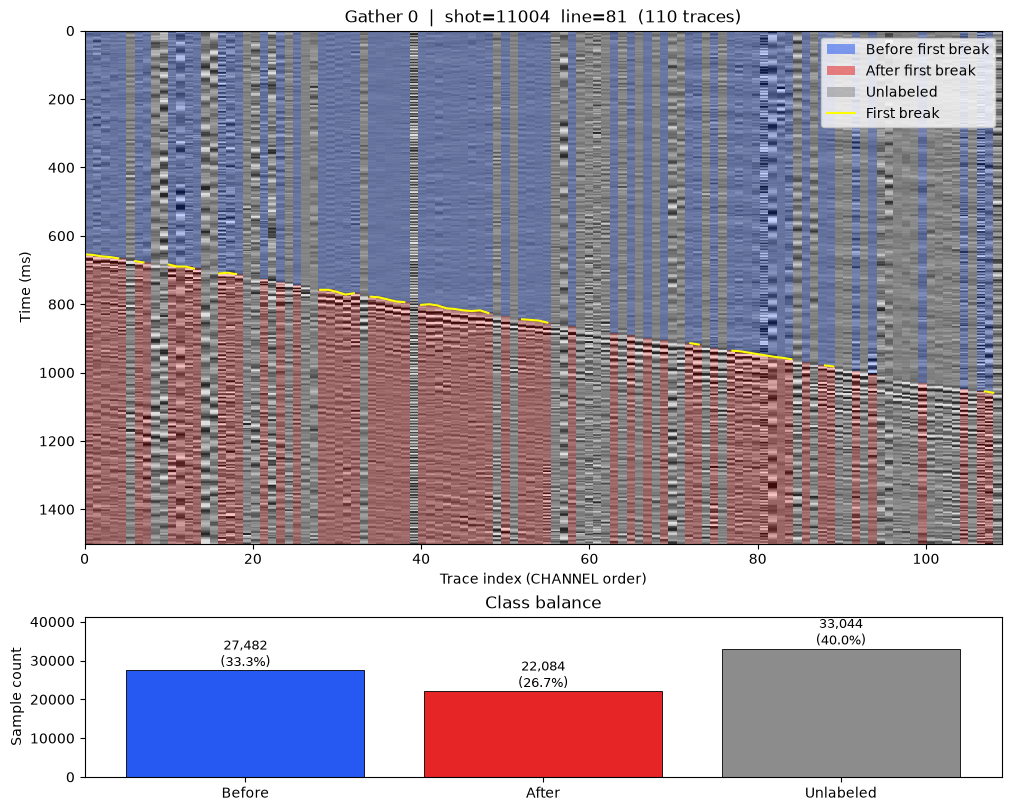

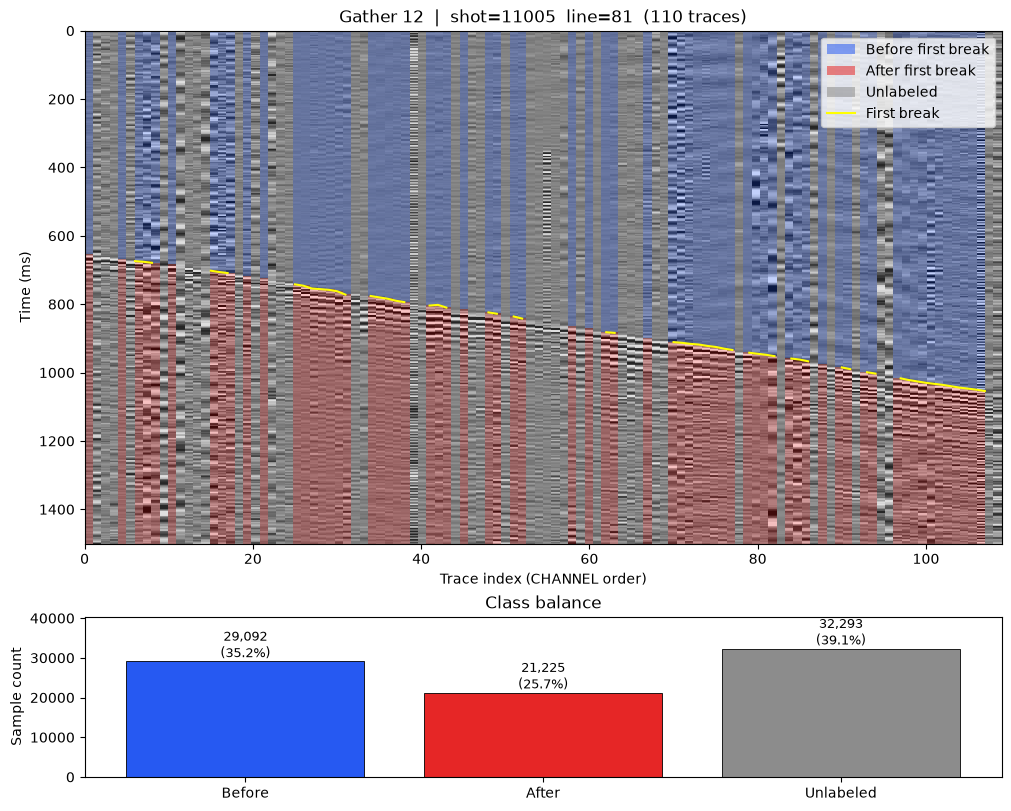

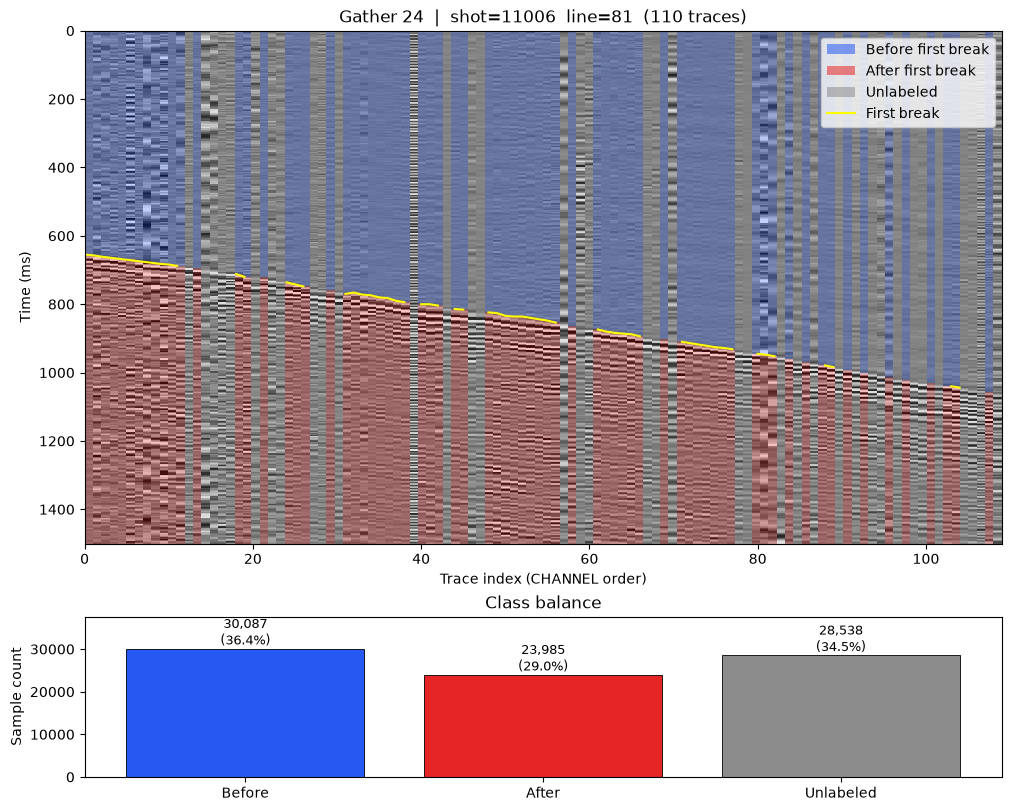

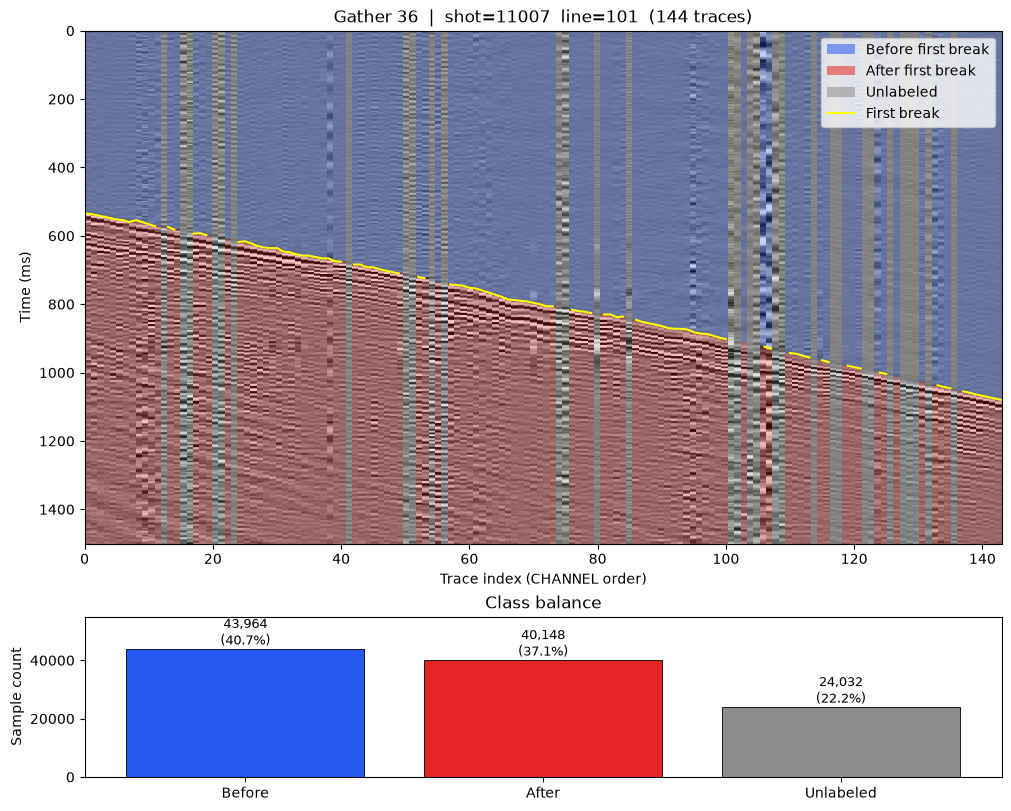

Saved [PosixPath('/home/mika/dev/seismic_activity/output/predict_brunswick/preview_gt_0.png'), PosixPath('/home/mika/dev/seismic_activity/output/predict_brunswick/preview_gt_1.png'), PosixPath('/home/mika/dev/seismic_activity/output/predict_brunswick/preview_gt_2.png'), PosixPath('/home/mika/dev/seismic_activity/output/predict_brunswick/preview_gt_3.png')]


In [15]:
def batch_to_gather(batch: dict, i: int) -> ShotGather:
    """Crop collate padding and build a viewer ShotGather (GT picks only)."""
    n_tr = int(batch["trace_count"][i])
    n_sa = int(batch["sample_count"][i])
    traces = batch["samples"][i, :n_tr, :n_sa].detach().cpu().numpy()
    fb_ms = batch["first_break_timestamps"][i, :n_tr].detach().cpu().numpy().astype(np.float64)
    bad = batch["bad_first_breaks_mask"][i, :n_tr].detach().cpu().numpy().astype(bool)
    fb_ms = fb_ms.copy()
    fb_ms[bad | (fb_ms <= 0)] = np.nan

    rec_ids = batch["rec_ids"][i, :n_tr].detach().cpu().numpy()
    rec_coords = batch["rec_coords"][i, :n_tr].detach().cpu().numpy()
    rec_x = rec_coords[:, 0] if rec_coords.ndim == 2 else np.zeros(n_tr)
    rec_y = rec_coords[:, 1] if rec_coords.ndim == 2 and rec_coords.shape[1] > 1 else np.zeros(n_tr)

    offset = None
    if batch.get("offset_distances") is not None:
        offset = batch["offset_distances"][i, :n_tr, 0].detach().cpu().numpy()

    dt_ms = batch["sample_rate_ms"]
    dt_ms = float(dt_ms[i] if getattr(dt_ms, "ndim", 0) else dt_ms)

    return ShotGather(
        shot_id=int(batch["shot_id"][i]),
        traces=traces,
        first_breaks_ms=fb_ms,
        channel=rec_ids,
        rec_x=rec_x,
        rec_y=rec_y,
        sample_rate_us=dt_ms * 1000.0,
        offset=offset,
        line_id=int(batch["rec_line_id"][i]),
        gather_id=int(batch["gather_id"][i]),
    )


def decode_fb_picks(raw_preds, model):
    """Logits → per-trace sample index, matching ``FBPEvaluator``.

    ``model.segm_class_count`` is ``head_class_count`` (2 logits), not the config
    scheme (1 = Not-FB / FB). Passing 2 into ``get_regr_preds_from_raw_preds``
    uses “first sample above threshold”; with threshold 0.0 that is always index 0.
    """
    scheme = int(model.test_evaluator.segm_class_count)
    thresh = float(model.test_evaluator.segm_first_break_prob_threshold)
    return metrics_utils.get_regr_preds_from_raw_preds(
        raw_preds=raw_preds,
        segm_class_count=scheme,
        prob_threshold=thresh,
    )


def overlay_predicted_picks(ax, gather: ShotGather, pred_idx: np.ndarray) -> dict:
    n_tr = gather.n_traces
    dt_ms = gather.sample_rate_us / 1000.0
    pred = np.asarray(pred_idx[:n_tr], dtype=np.float64)
    x = np.arange(n_tr, dtype=np.float64)
    y = pred * dt_ms
    y[pred <= 0] = np.nan
    ax.plot(x, y, color="lime", linewidth=2.0, label="Predicted FB")
    ax.legend(loc="upper right")
    stats = residual_stats(gather, pred)
    text = format_residual_stats(stats)
    ax.text(
        0.01,
        0.01,
        text,
        transform=ax.transAxes,
        fontsize=9,
        color="white",
        va="bottom",
        ha="left",
        family="monospace",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="black", alpha=0.65),
    )
    print(text.replace("\n", "  |  "))
    return stats


def residual_stats(gather: ShotGather, pred_idx: np.ndarray) -> dict:
    """Residuals on traces with a GT pick. Sample 0 / NaN predictions still count (as misses)."""
    dt_ms = gather.sample_rate_us / 1000.0
    n_tr = gather.n_traces
    pred = np.asarray(pred_idx[:n_tr], dtype=np.float64)
    gt_ms = np.asarray(gather.first_breaks_ms[:n_tr], dtype=np.float64)
    labeled = np.isfinite(gt_ms)
    out: dict = {
        "n_labeled": int(labeled.sum()),
        "n_traces": int(n_tr),
        "n_nopick": int((labeled & (pred <= 0)).sum()),
    }
    if out["n_labeled"] == 0:
        return out
    gt_px = np.rint(gt_ms / dt_ms)
    err_px = (pred - gt_px)[labeled]
    err_ms = err_px * dt_ms
    abs_px = np.abs(err_px)
    out.update(
        mae_px=float(np.mean(abs_px)),
        mbe_px=float(np.mean(err_px)),
        rmse_px=float(np.sqrt(np.mean(err_px**2))),
        median_abs_px=float(np.median(abs_px)),
        mae_ms=float(np.mean(np.abs(err_ms))),
        mbe_ms=float(np.mean(err_ms)),
        hit1=float(np.mean(abs_px < 1)),
        hit3=float(np.mean(abs_px < 3)),
        hit5=float(np.mean(abs_px < 5)),
    )
    return out


def format_residual_stats(stats: dict) -> str:
    if stats["n_labeled"] == 0:
        return f"residuals: no labeled traces ({stats['n_traces']} traces)"
    nopick = stats.get("n_nopick", 0)
    extra = f"  nopick={nopick}" if nopick else ""
    return (
        f"n={stats['n_labeled']}/{stats['n_traces']}{extra}  "
        f"MAE={stats['mae_px']:.2f} px ({stats['mae_ms']:.2f} ms)  "
        f"MBE={stats['mbe_px']:+.2f} px ({stats['mbe_ms']:+.2f} ms)\n"
        f"HitRate 1/3/5 px: {stats['hit1']:.1%} / {stats['hit3']:.1%} / {stats['hit5']:.1%}  "
        f"RMSE={stats['rmse_px']:.2f} px  med|e|={stats['median_abs_px']:.1f} px"
    )


preview_batch = next(iter(pred_loader))
n_show = min(N_SHOW, preview_batch["samples"].shape[0])
saved = []
for i in range(n_show):
    gather = batch_to_gather(preview_batch, i)
    fig = plot_shot_gather(gather, show_first_breaks=True, highlight_regions=True)
    out = OUTPUT_ROOT / f"preview_gt_{i}.png"
    fig.savefig(out, dpi=120)
    plt.show()
    saved.append(out)
print("Saved", saved)

## Prediction

Forward pass is vanilla PyTorch (`model.eval()`, `torch.no_grad()`), using the same `prepare_input_features` path Lightning uses in training:

1. Build input `(B, C, traces, samples)` — amplitudes + 3 offset channels when `use_dist_offsets=True` (**C = 4**).
2. U-Net logits `(B, 2, traces, samples)`.
3. Per-trace pick = argmax of the **First Break** class (same as `HitRate*` in training). Sample index `0` is treated as no-pick.
4. `FBPEvaluator.ingest` compares picks to GT on labeled traces (`HitRate1/3/5px`, MAE, MBE).

Set `MAX_PRED_BATCHES` &gt; 0 for a short smoke run.


In [6]:
if torch.cuda.is_available():
    print("Will predict on GPU.")
    model = model.cuda()
else:
    print("Will predict on CPU.")

model.eval()
model.test_evaluator.reset()

n_batches = len(pred_loader)
if MAX_PRED_BATCHES > 0:
    n_batches = min(n_batches, MAX_PRED_BATCHES)
    print(f"Limiting to {n_batches} batches (FBP_MAX_PRED_BATCHES)")

loader_wrapper = tqdm.tqdm(pred_loader, total=n_batches)
for batch_idx, batch in enumerate(loader_wrapper):
    if batch_idx >= n_batches:
        break
    with torch.no_grad():
        input_tensor = model_utils.prepare_input_features(
            batch,
            use_dist_offsets=model.use_dist_offsets,
            use_first_break_prior=model.use_first_break_prior,
        ).to(model.device).float()
        predictions = model(input_tensor)
        # logits: (B, class_count, traces, samples) → one sample index per trace
        _pred_idx, _pred_prob = decode_fb_picks(predictions, model)
        metrics = model.test_evaluator.ingest(batch, batch_idx, predictions.detach())
        if metrics:
            loader_wrapper.set_postfix({k: f"{v:.3f}" for k, v in list(metrics.items())[:3]})

Will predict on GPU.


100%|██████████| 1260/1260 [01:43<00:00, 12.23it/s, HitRate1px=0.769, HitRate3px=0.970, HitRate5px=0.987]


The Lightning module already owns a **test** `FBPEvaluator` (same HitRate / MAE / MBE definitions as training). The loop above ingested every batch, so `summarize()` is the full-split aggregate — not a mean of per-batch scores.

This only works if ground-truth picks were in the minibatches (they are, for these HDF5/NPZ sites).


In [7]:
test_results_map = model.test_evaluator.summarize()
print(f"Results for {SITE_NAME} ({split} split, {backend}):")
if not test_results_map:
    print("  (empty — no labeled traces ingested?)")
for key, val in test_results_map.items():
    print(f"  {key}: {val}")

Results for Brunswick (valid split, npz):
  HitRate1px: 0.8789148232100019
  HitRate3px: 0.9721937790691455
  HitRate5px: 0.982526666063769
  MeanBiasError: 3.9403053579121075
  MeanAbsoluteError: 4.276088205864249


Predicted picks (**lime**) over ground truth (**yellow**) on the first preview batch. Blue/red/gray tint is still the **GT** first-break regions. Each figure prints residual stats (MAE / MBE / HitRate) for that gather.


Gather 0 (shot=11004, line=81):
n=66/110  MAE=0.35 px (0.70 ms)  MBE=-0.11 px (-0.21 ms)  |  HitRate 1/3/5 px: 72.7% / 97.0% / 100.0%  RMSE=0.75 px  med|e|=0.0 px


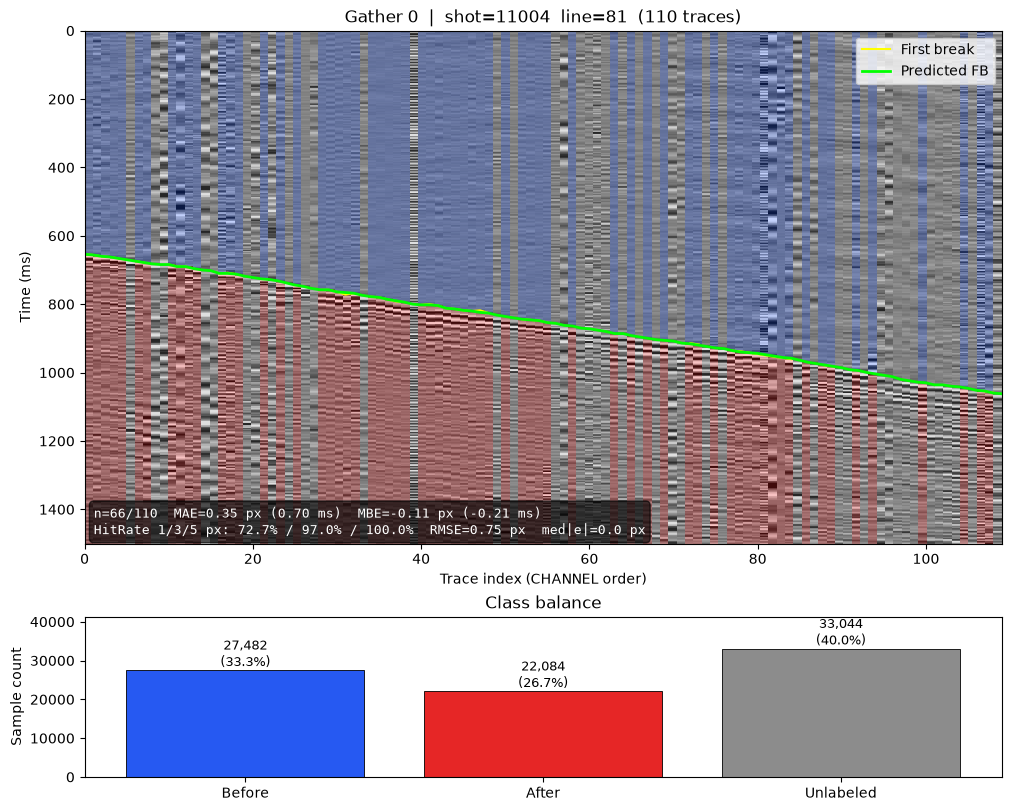

Gather 12 (shot=11005, line=81):
n=67/110  MAE=0.54 px (1.07 ms)  MBE=-0.15 px (-0.30 ms)  |  HitRate 1/3/5 px: 58.2% / 97.0% / 100.0%  RMSE=0.91 px  med|e|=0.0 px


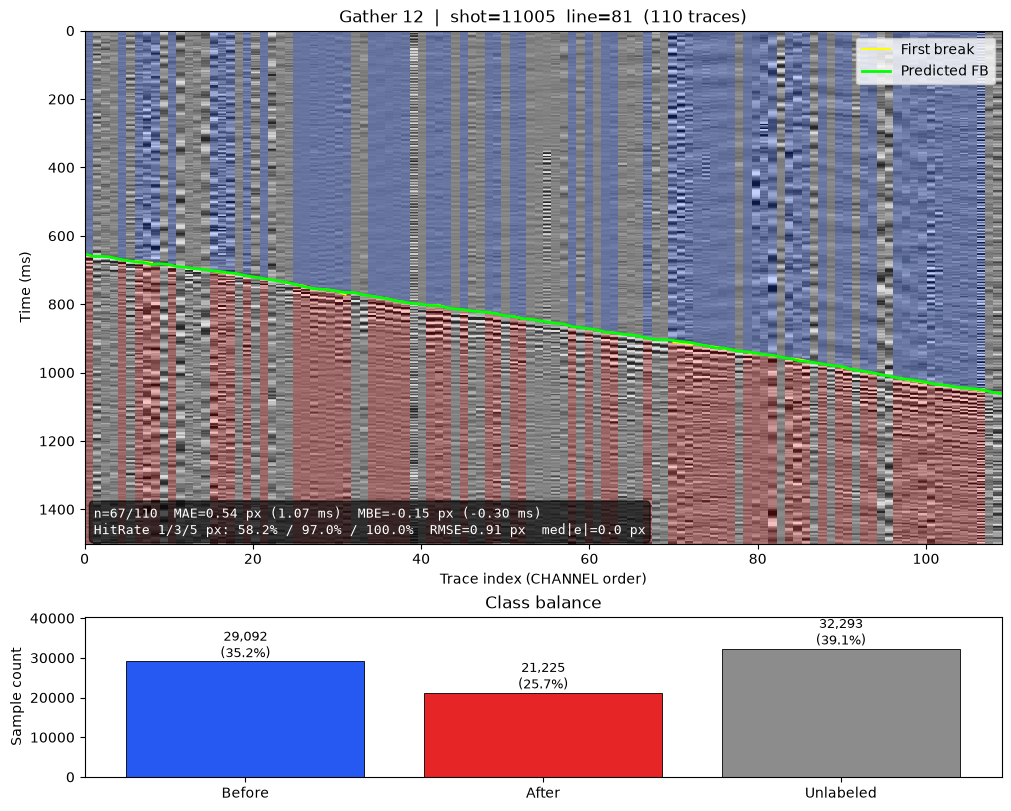

Gather 24 (shot=11006, line=81):
n=72/110  MAE=0.56 px (1.11 ms)  MBE=-0.19 px (-0.39 ms)  |  HitRate 1/3/5 px: 56.9% / 98.6% / 100.0%  RMSE=0.91 px  med|e|=0.0 px


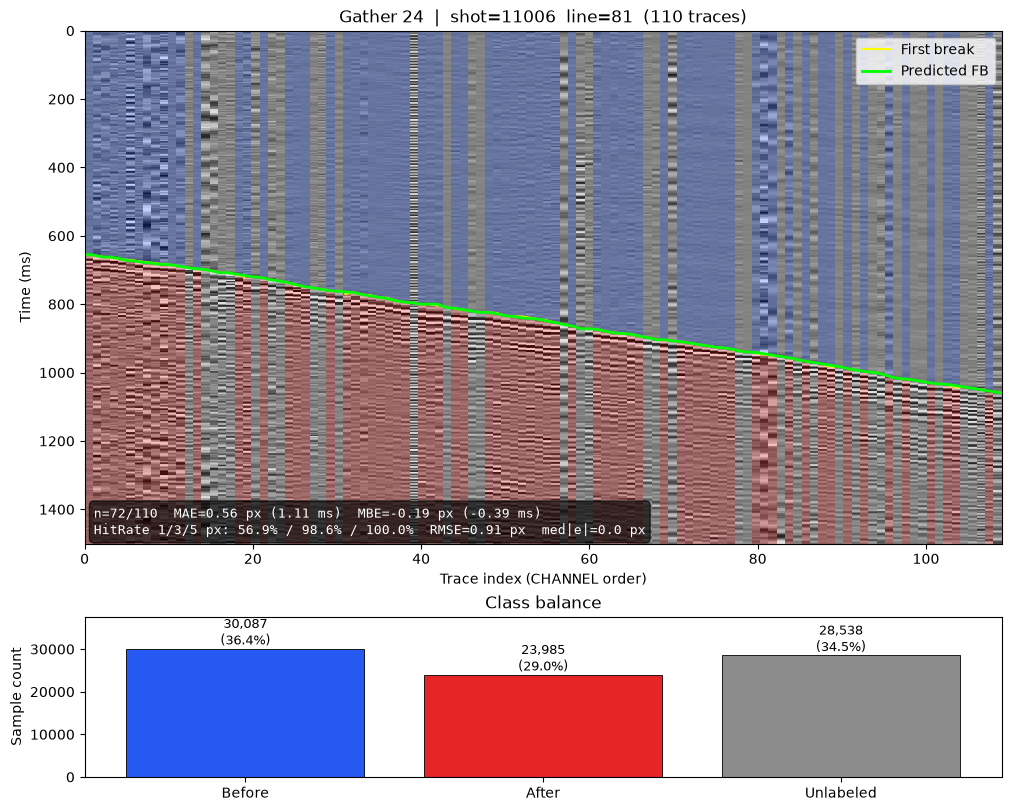

Gather 36 (shot=11007, line=101):
n=112/144  MAE=0.86 px (1.71 ms)  MBE=+0.75 px (+1.50 ms)  |  HitRate 1/3/5 px: 62.5% / 88.4% / 95.5%  RMSE=1.83 px  med|e|=0.0 px


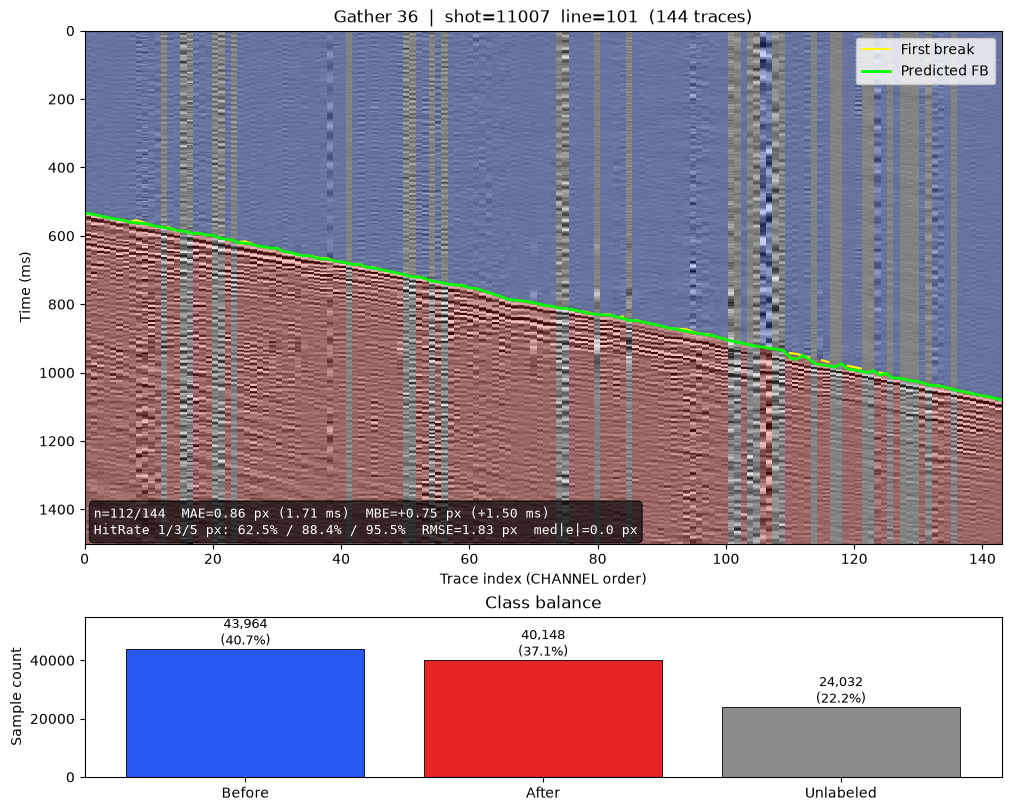

Saved [PosixPath('/home/mika/dev/seismic_activity/output/predict_brunswick/preview_pred_0.png'), PosixPath('/home/mika/dev/seismic_activity/output/predict_brunswick/preview_pred_1.png'), PosixPath('/home/mika/dev/seismic_activity/output/predict_brunswick/preview_pred_2.png'), PosixPath('/home/mika/dev/seismic_activity/output/predict_brunswick/preview_pred_3.png')]


In [16]:
minibatch = next(iter(pred_loader))
with torch.no_grad():
    input_tensor = model_utils.prepare_input_features(
        minibatch,
        use_dist_offsets=model.use_dist_offsets,
        use_first_break_prior=model.use_first_break_prior,
    ).to(model.device).float()
    pred_logits = model(input_tensor)
    pred_idx, _ = decode_fb_picks(pred_logits, model)
pred_idx_np = pred_idx.detach().cpu().numpy()

n_show = min(N_SHOW, minibatch["samples"].shape[0])
saved = []
for i in range(n_show):
    gather = batch_to_gather(minibatch, i)
    fig = plot_shot_gather(gather, show_first_breaks=True, highlight_regions=True)
    print(f"Gather {gather.gather_id} (shot={gather.shot_id}, line={gather.line_id}):")
    overlay_predicted_picks(fig.axes[0], gather, pred_idx_np[i])
    out = OUTPUT_ROOT / f"preview_pred_{i}.png"
    fig.savefig(out, dpi=120)
    plt.show()
    saved.append(out)
print("Saved", saved)

**Bonus — test-time flip ensemble.** Most accuracy gains come from training, but at test time we can average logits from the gather and a **trace-wise flip** (then unflip, skipping collate padding). This costs a second forward pass.


In [9]:
def flip_then_collate(list_of_gathers):
    for gather in list_of_gathers:
        fbp_data_transforms.flip(gather)
    return fbp_data_module.fbp_batch_collate(
        list_of_gathers,
        pad_to_nearest_pow2=True,
    )


tta_loader = torch.utils.data.DataLoader(
    dataset=pred_parser,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=flip_then_collate,
)

model.test_evaluator.reset()
loader_wrapper = tqdm.tqdm(
    zip(pred_loader, tta_loader),
    total=n_batches,
)
for batch_idx, (batch, batch_flip) in enumerate(loader_wrapper):
    if batch_idx >= n_batches:
        break
    with torch.no_grad():
        input_tensor = model_utils.prepare_input_features(
            batch,
            use_dist_offsets=model.use_dist_offsets,
            use_first_break_prior=model.use_first_break_prior,
        ).to(model.device).float()
        predictions = model(input_tensor).detach()

        input_tensor_flip = model_utils.prepare_input_features(
            batch_flip,
            use_dist_offsets=model.use_dist_offsets,
            use_first_break_prior=model.use_first_break_prior,
        ).to(model.device).float()
        predictions_flip = model(input_tensor_flip).detach()
        assert predictions_flip.shape == predictions.shape

        predictions_unflip = torch.flip(predictions_flip, [2])  # dim 2 = trace axis
        for gather_idx in range(len(predictions_flip)):
            expected_trace_count = int(batch_flip["trace_count"][gather_idx].item())
            expected_padding_count = predictions_flip.shape[2] - expected_trace_count
            predictions[gather_idx, :, 0:expected_trace_count, :] = torch.mean(
                torch.stack([
                    predictions[gather_idx, :, 0:expected_trace_count, :],
                    predictions_unflip[gather_idx, :, expected_padding_count:, :],
                ]),
                dim=0,
            )

        metrics = model.test_evaluator.ingest(batch, batch_idx, predictions)
        if metrics:
            loader_wrapper.set_postfix({k: f"{v:.3f}" for k, v in list(metrics.items())[:3]})

tta_results_map = model.test_evaluator.summarize()
print(f"Results with TTA for {SITE_NAME}:")
for key, val in tta_results_map.items():
    if key in test_results_map:
        diff = val - test_results_map[key]
        print(f"  {key}: {val}  ({diff:+.4f} vs no TTA)")
    else:
        print(f"  {key}: {val}")

100%|██████████| 1260/1260 [03:10<00:00,  6.63it/s, HitRate1px=0.756, HitRate3px=0.980, HitRate5px=0.987]


Results with TTA for Brunswick:
  HitRate1px: 0.886799168001307  (+0.0079 vs no TTA)
  HitRate3px: 0.9738546647257253  (+0.0017 vs no TTA)
  HitRate5px: 0.983683840496632  (+0.0012 vs no TTA)
  MeanBiasError: 4.227827225105434  (+0.2875 vs no TTA)
  MeanAbsoluteError: 4.512235417900419  (+0.2361 vs no TTA)
